# Project Milestone 1

In [ ]:
import sqlite3
import pandas as pd

# Loaded raw CSV
df = pd.read_csv('team_traditional.csv')

# Create a SQLite database file and connect to it
conn = sqlite3.connect('capstone.db')

# Write the dataframe into a table in that database
df.to_sql('team_traditional', conn, if_exists='replace', index=False)

73404

In [ ]:
query = "SELECT * FROM team_traditional WHERE season = 2025 AND type = 'regular'"
df_2025 = pd.read_sql(query, conn)

print(len(df_2025))
df_2025.head()

2460


,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
0,22400061,2024-10-22,regular,1610612738,BOS,BOS,NYK,48.0,132.0,48.0,...,29.0,40.0,33.0,4.0,6.0,3.0,15.0,23.0,1.0,2025
1,22400061,2024-10-22,regular,1610612752,NYK,BOS,NYK,48.0,109.0,43.0,...,29.0,34.0,20.0,12.0,2.0,3.0,12.0,-23.0,0.0,2025
2,22400062,2024-10-22,regular,1610612747,LAL,LAL,MIN,48.0,110.0,42.0,...,31.0,46.0,22.0,7.0,7.0,8.0,22.0,7.0,1.0,2025
3,22400062,2024-10-22,regular,1610612750,MIN,LAL,MIN,48.0,103.0,35.0,...,35.0,47.0,17.0,16.0,4.0,1.0,22.0,-7.0,0.0,2025
4,22400063,2024-10-23,regular,1610612754,IND,DET,IND,48.0,115.0,42.0,...,32.0,39.0,32.0,15.0,10.0,8.0,23.0,6.0,1.0,2025


In [ ]:
# Check missing values for every column
df_2025.isnull().sum()

,0
gameid,0
date,0
type,0
teamid,0
team,0
home,0
away,0
MIN,0
PTS,0
FGM,0


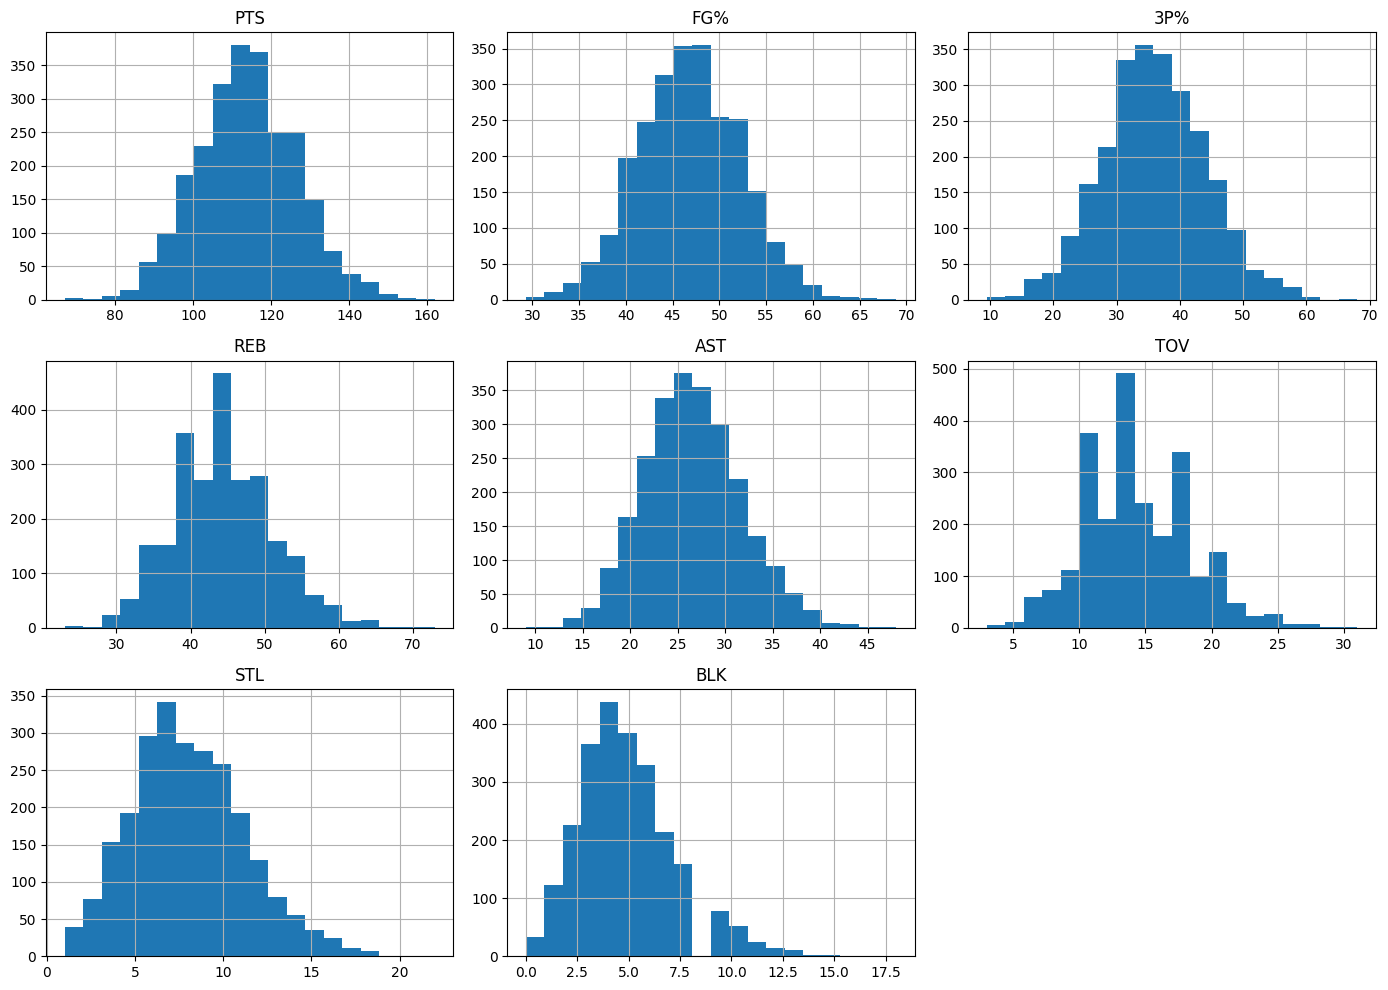

In [ ]:

import matplotlib.pyplot as plt

stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']

df_2025[stats].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

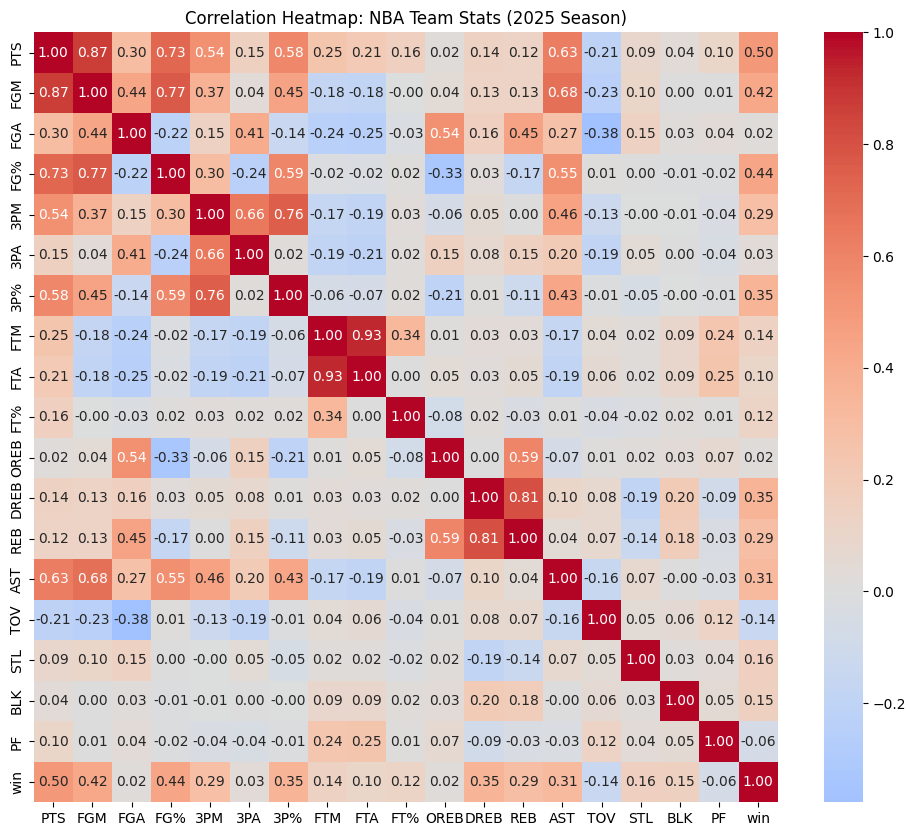

In [ ]:
import seaborn as sns

statistics = ['PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%',
                 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'win']

plt.figure(figsize=(12, 10))
sns.heatmap(df_2025[statistics].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: NBA Team Stats (2025 Season)')
plt.show()

# Project Milestone 2

In [71]:
df_2025.head(10)

,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season,opponent,is_home,ast_tov_ratio,rest_days,PTS_roll5,PTS_roll10,FG%_roll5,FG%_roll10,3P%_roll5,3P%_roll10,REB_roll5,REB_roll10,AST_roll5,AST_roll10,TOV_roll5,TOV_roll10,STL_roll5,STL_roll10,BLK_roll5,BLK_roll10,ast_tov_roll5,ast_tov_roll10
0,22400064,2024-10-23,regular,1610612737,ATL,ATL,BKN,48.0,120.0,39.0,80.0,48.8,9.0,28.0,32.1,33.0,46.0,71.7,12.0,33.0,45.0,25.0,16.0,12.0,9.0,20.0,4.0,1.0,2025,BKN,1,1.562500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22400079,2024-10-25,regular,1610612737,ATL,ATL,CHA,48.0,125.0,39.0,81.0,48.1,14.0,38.0,36.8,33.0,38.0,86.8,7.0,32.0,39.0,25.0,14.0,11.0,9.0,28.0,5.0,1.0,2025,CHA,1,1.785714,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22400100,2024-10-27,regular,1610612737,ATL,OKC,ATL,48.0,104.0,36.0,91.0,39.6,10.0,31.0,32.3,22.0,29.0,75.9,17.0,32.0,49.0,24.0,20.0,7.0,4.0,23.0,-24.0,0.0,2025,OKC,0,1.200000,2.0,122.500000,122.500000,48.45,48.450000,34.450000,34.450000,42.000000,42.000000,25.000000,25.000000,15.000000,15.000000,11.5,11.500000,9.000000,9.000000,1.674107,1.674107
3,22400103,2024-10-28,regular,1610612737,ATL,ATL,WAS,48.0,119.0,39.0,81.0,48.1,15.0,40.0,37.5,26.0,36.0,72.2,6.0,33.0,39.0,32.0,16.0,12.0,7.0,22.0,-2.0,0.0,2025,WAS,1,2.000000,1.0,116.333333,116.333333,45.50,45.500000,33.733333,33.733333,44.333333,44.333333,24.666667,24.666667,16.666667,16.666667,10.0,10.000000,7.333333,7.333333,1.516071,1.516071
4,22400121,2024-10-30,regular,1610612737,ATL,WAS,ATL,48.0,120.0,45.0,95.0,47.4,12.0,39.0,30.8,18.0,21.0,85.7,12.0,29.0,41.0,28.0,17.0,10.0,3.0,19.0,-13.0,0.0,2025,WAS,0,1.647059,2.0,117.000000,117.000000,46.15,46.150000,34.675000,34.675000,43.000000,43.000000,26.500000,26.500000,16.500000,16.500000,10.5,10.500000,7.250000,7.250000,1.637054,1.637054
5,22400135,2024-11-01,regular,1610612737,ATL,ATL,SAC,48.0,115.0,41.0,92.0,44.6,19.0,50.0,38.0,14.0,18.0,77.8,8.0,32.0,40.0,30.0,13.0,8.0,4.0,22.0,-8.0,0.0,2025,SAC,1,2.307692,2.0,117.600000,117.600000,46.40,46.400000,33.900000,33.900000,42.600000,42.600000,26.800000,26.800000,16.600000,16.600000,10.4,10.400000,6.400000,6.400000,1.639055,1.639055
6,22400152,2024-11-03,regular,1610612737,ATL,NOP,ATL,48.0,126.0,50.0,88.0,56.8,15.0,36.0,41.7,11.0,12.0,91.7,10.0,31.0,41.0,29.0,16.0,10.0,3.0,17.0,15.0,1.0,2025,NOP,0,1.812500,2.0,116.600000,117.166667,45.56,46.100000,35.080000,34.583333,41.600000,42.166667,27.800000,27.333333,16.000000,16.000000,9.6,10.000000,5.400000,6.000000,1.788093,1.750494
7,22400157,2024-11-04,regular,1610612737,ATL,ATL,BOS,48.0,93.0,37.0,89.0,41.6,6.0,31.0,19.4,13.0,16.0,81.3,8.0,35.0,43.0,23.0,20.0,9.0,3.0,13.0,-30.0,0.0,2025,BOS,1,1.150000,1.0,116.800000,118.428571,47.30,47.628571,36.060000,35.600000,42.000000,42.000000,28.600000,27.571429,16.400000,16.000000,9.4,10.000000,4.200000,5.571429,1.793450,1.759352
8,22400171,2024-11-06,regular,1610612737,ATL,ATL,NYK,48.0,121.0,45.0,100.0,45.0,15.0,38.0,39.5,16.0,22.0,72.7,16.0,32.0,48.0,31.0,8.0,12.0,4.0,14.0,5.0,1.0,2025,NYK,1,3.875000,2.0,114.600000,115.250000,47.70,46.875000,33.480000,33.575000,40.800000,42.125000,28.400000,27.000000,16.400000,16.500000,9.8,9.875000,4.000000,5.250000,1.783450,1.683183
9,22400185,2024-11-08,regular,1610612737,ATL,DET,ATL,48.0,121.0,44.0,97.0,45.4,15.0,36.0,41.7,18.0,23.0,78.3,15.0,29.0,44.0,30.0,18.0,12.0,7.0,21.0,-1.0,0.0,2025,DET,0,1.666667,2.0,115.000000,115.888889,47.08,46.666667,33.880000,34.233333,42.600000,42.777778,28.200000,27.444444,14.800000,15.555556,9.8,10.111111,3.400000,5.111111,2.158450,1.926718


In [ ]:
# Check missing values for every column
df_2025.isnull().sum()

,0
gameid,0
date,0
type,0
teamid,0
team,0
home,0
away,0
MIN,0
PTS,0
FGM,0


In [ ]:
# Check missing values as a percentage per column
print((df_2025.isnull().sum() / len(df_2025)) * 100)

gameid    0.0
date      0.0
type      0.0
teamid    0.0
team      0.0
home      0.0
away      0.0
MIN       0.0
PTS       0.0
FGM       0.0
FGA       0.0
FG%       0.0
3PM       0.0
3PA       0.0
3P%       0.0
FTM       0.0
FTA       0.0
FT%       0.0
OREB      0.0
DREB      0.0
REB       0.0
AST       0.0
TOV       0.0
STL       0.0
BLK       0.0
PF        0.0
+/-       0.0
win       0.0
season    0.0
dtype: float64


win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


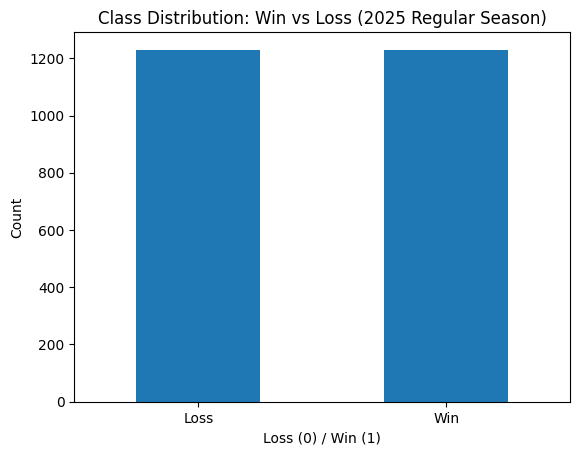

In [69]:
# Part 2: check data imbalance

# Check class distribution of the target variable
print(df_2025['win'].value_counts(normalize=True))

# Bar chart of class distribution
import matplotlib.pyplot as plt

df_2025['win'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution: Win vs Loss (2025 Regular Season)')
plt.xlabel('Loss (0) / Win (1)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Loss', 'Win'], rotation=0)
plt.show()

In [61]:
#part 3:feature engineering

# Convert date to datetime and sort chronologically per team
df_2025['date'] = pd.to_datetime(df_2025['date'])
df_2025 = df_2025.sort_values(['team', 'date']).reset_index(drop=True)

In [ ]:
# New features: opponent, home/away, assist to turnover ratio, rest days
df_2025['opponent'] = df_2025.apply(lambda r: r['away'] if r['team']==r['home'] else r['home'], axis=1)
df_2025['is_home'] = (df_2025['team'] == df_2025['home']).astype(int)
df_2025['ast_tov_ratio'] = df_2025['AST'] / df_2025['TOV'].replace(0, 1)
df_2025['rest_days'] = df_2025.groupby('team')['date'].diff().dt.days

In [ ]:
# Rolling averages (5-game and 10-game)
stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']

for s in stats:
    shifted = df_2025.groupby('team')[s].shift(1)
    df_2025[f'{s}_roll5'] = shifted.groupby(df_2025['team']).rolling(5, min_periods=2).mean().reset_index(drop=True)
    df_2025[f'{s}_roll10'] = shifted.groupby(df_2025['team']).rolling(10, min_periods=2).mean().reset_index(drop=True)

In [ ]:
# Rolling AST/TOV ratio
shifted_ratio = df_2025.groupby('team')['ast_tov_ratio'].shift(1)
df_2025['ast_tov_roll5'] = shifted_ratio.groupby(df_2025['team']).rolling(5, min_periods=2).mean().reset_index(drop=True)
df_2025['ast_tov_roll10'] = shifted_ratio.groupby(df_2025['team']).rolling(10, min_periods=2).mean().reset_index(drop=True)

In [ ]:
# Explicitly define feature columns, then drop leaky/irrelevant columns and early-season rows with incomplete rolling history
feature_cols = [c for c in df_2025.columns if 'roll5' in c or 'roll10' in c] + ['is_home', 'rest_days']
id_cols = ['gameid', 'date', 'team', 'opponent']
keep_cols = id_cols + feature_cols + ['win']

df_model = df_2025[keep_cols].dropna(subset=feature_cols).reset_index(drop=True)

print(df_model.shape)
print(df_model.columns.tolist())

(2400, 25)
['gameid', 'date', 'team', 'opponent', 'PTS_roll5', 'PTS_roll10', 'FG%_roll5', 'FG%_roll10', '3P%_roll5', '3P%_roll10', 'REB_roll5', 'REB_roll10', 'AST_roll5', 'AST_roll10', 'TOV_roll5', 'TOV_roll10', 'STL_roll5', 'STL_roll10', 'BLK_roll5', 'BLK_roll10', 'ast_tov_roll5', 'ast_tov_roll10', 'is_home', 'rest_days', 'win']


In [70]:
df_model.head(10)

,gameid,date,team,opponent,PTS_roll5,FG%_roll5,3P%_roll5,REB_roll5,AST_roll5,TOV_roll5,STL_roll5,BLK_roll5,ast_tov_roll5,PTS_roll10,FG%_roll10,3P%_roll10,REB_roll10,AST_roll10,TOV_roll10,STL_roll10,BLK_roll10,ast_tov_roll10,is_home,rest_days,win
0,22400100,2024-10-27,ATL,OKC,122.500000,48.45,34.450000,42.000000,25.000000,15.000000,11.5,9.000000,1.674107,122.500000,48.450000,34.450000,42.000000,25.000000,15.000000,11.500000,9.000000,1.674107,0,2.0,0.0
1,22400103,2024-10-28,ATL,WAS,116.333333,45.50,33.733333,44.333333,24.666667,16.666667,10.0,7.333333,1.516071,116.333333,45.500000,33.733333,44.333333,24.666667,16.666667,10.000000,7.333333,1.516071,1,1.0,0.0
2,22400121,2024-10-30,ATL,WAS,117.000000,46.15,34.675000,43.000000,26.500000,16.500000,10.5,7.250000,1.637054,117.000000,46.150000,34.675000,43.000000,26.500000,16.500000,10.500000,7.250000,1.637054,0,2.0,0.0
3,22400135,2024-11-01,ATL,SAC,117.600000,46.40,33.900000,42.600000,26.800000,16.600000,10.4,6.400000,1.639055,117.600000,46.400000,33.900000,42.600000,26.800000,16.600000,10.400000,6.400000,1.639055,1,2.0,0.0
4,22400152,2024-11-03,ATL,NOP,116.600000,45.56,35.080000,41.600000,27.800000,16.000000,9.6,5.400000,1.788093,117.166667,46.100000,34.583333,42.166667,27.333333,16.000000,10.000000,6.000000,1.750494,0,2.0,1.0
5,22400157,2024-11-04,ATL,BOS,116.800000,47.30,36.060000,42.000000,28.600000,16.400000,9.4,4.200000,1.793450,118.428571,47.628571,35.600000,42.000000,27.571429,16.000000,10.000000,5.571429,1.759352,1,1.0,0.0
6,22400171,2024-11-06,ATL,NYK,114.600000,47.70,33.480000,40.800000,28.400000,16.400000,9.8,4.000000,1.783450,115.250000,46.875000,33.575000,42.125000,27.000000,16.500000,9.875000,5.250000,1.683183,1,2.0,1.0
7,22400185,2024-11-08,ATL,DET,115.000000,47.08,33.880000,42.600000,28.200000,14.800000,9.8,3.400000,2.158450,115.888889,46.666667,34.233333,42.777778,27.444444,15.555556,10.111111,5.111111,1.926718,0,2.0,0.0
8,22400198,2024-11-09,ATL,CHI,115.200000,46.68,36.060000,43.200000,28.600000,15.000000,10.2,4.200000,2.162372,116.400000,46.540000,34.980000,42.900000,27.700000,15.800000,10.300000,5.300000,1.900713,1,1.0,0.0
9,22400001,2024-11-12,ATL,BOS,114.800000,46.98,34.660000,43.000000,28.800000,15.200000,10.2,4.400000,2.143690,115.700000,46.270000,34.870000,42.300000,28.300000,15.600000,9.900000,4.900000,1.965892,0,3.0,1.0


In [ ]:
# Part 4:impact of preprocessing

# Before/after row count from dropping early-season rows (rolling window warm-up)
rows_before = len(df_2025)
rows_after = len(df_model)

print(f"Rows before dropping early-season rows: {rows_before}")
print(f"Rows after dropping early-season rows: {rows_after}")


Rows before dropping early-season rows: 2460
Rows after dropping early-season rows: 2400


In [ ]:
# Confirm missing values and class balance were unaffected by preprocessing
print("Missing values before (raw stats):", df_2025[['PTS','FG%','3P%','REB','AST','TOV','STL','BLK']].isnull().sum().sum())
print("Missing values after (feature columns):", df_model[feature_cols].isnull().sum().sum())

print("\nClass balance before:")
print(df_2025['win'].value_counts(normalize=True))
print("\nClass balance after:")
print(df_model['win'].value_counts(normalize=True))

Missing values before (raw stats): 0
Missing values after (feature columns): 0

Class balance before:
win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Class balance after:
win
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


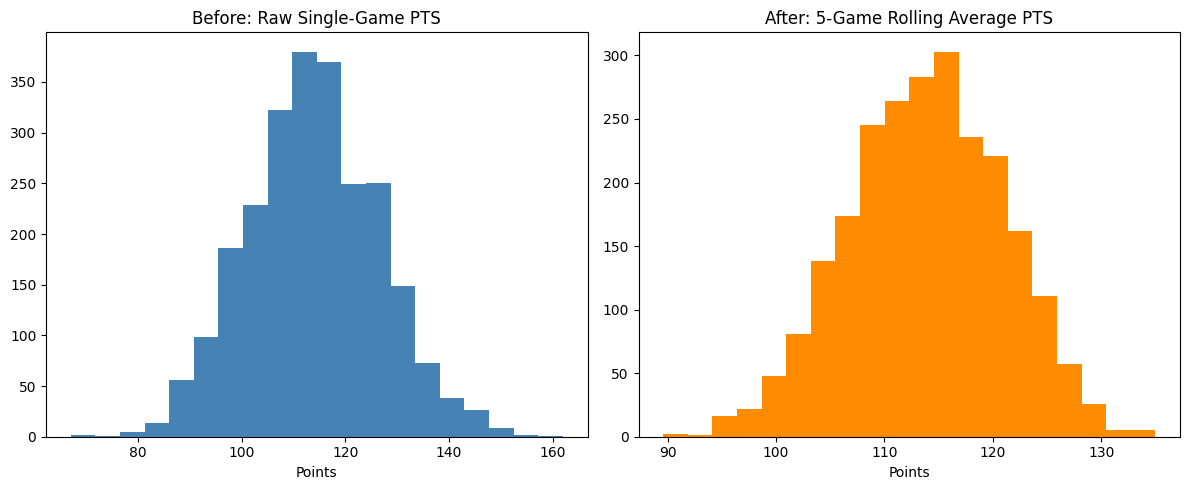

In [ ]:
# Visual before/after: raw PTS distribution vs. rolling PTS_roll5 distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_2025['PTS'], bins=20, color='steelblue')
axes[0].set_title('Before: Raw Single-Game PTS')
axes[0].set_xlabel('Points')

axes[1].hist(df_model['PTS_roll5'], bins=20, color='darkorange')
axes[1].set_title('After: 5-Game Rolling Average PTS')
axes[1].set_xlabel('Points')

plt.tight_layout()
plt.show()

In [ ]:
#part 5 - summary statistics
df_model.describe()

,gameid,date,PTS_roll5,FG%_roll5,3P%_roll5,REB_roll5,AST_roll5,TOV_roll5,STL_roll5,BLK_roll5,...,3P%_roll10,REB_roll10,AST_roll10,TOV_roll10,STL_roll10,BLK_roll10,ast_tov_roll10,is_home,rest_days,win
count,2.400000e+03,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,...,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,2.240063e+07,2025-01-19 21:52:48,113.819729,46.803326,35.993692,44.074104,26.529417,14.317160,8.205979,4.896597,...,35.969909,44.088417,26.495446,14.355650,8.214439,4.929619,2.034397,0.498333,2.122500,0.500000
min,2.240000e+07,2024-10-26 00:00:00,89.600000,37.360000,19.500000,33.000000,17.250000,7.600000,3.200000,1.500000,...,19.500000,35.000000,17.250000,9.000000,3.500000,1.500000,1.026738,0.000000,1.000000,0.000000
25%,2.240033e+07,2024-12-05 00:00:00,109.150000,44.800000,33.460000,41.600000,24.400000,12.800000,7.000000,4.000000,...,34.120000,42.100000,24.600000,13.100000,7.300000,4.200000,1.758643,0.000000,2.000000,0.000000
50%,2.240063e+07,2025-01-20 00:00:00,114.000000,46.800000,36.060000,44.000000,26.400000,14.200000,8.200000,4.800000,...,36.005000,44.000000,26.400000,14.300000,8.100000,4.800000,2.013213,0.000000,2.000000,0.500000
75%,2.240093e+07,2025-03-06 00:00:00,119.000000,48.800000,38.545000,46.400000,28.600000,15.800000,9.200000,5.600000,...,37.890000,45.925000,28.400000,15.500000,9.000000,5.500000,2.272764,1.000000,2.000000,1.000000
max,2.240123e+07,2025-04-13 00:00:00,135.000000,55.800000,50.420000,58.500000,36.600000,23.000000,14.400000,10.000000,...,44.630000,58.500000,36.500000,23.000000,14.000000,10.000000,4.875000,1.000000,9.000000,1.000000
std,3.490163e+02,NaN,7.089717,2.949655,3.858540,3.544053,3.028806,2.105722,1.672738,1.275162,...,3.017735,2.906407,2.647053,1.758585,1.371001,1.043472,0.369223,0.500101,1.007679,0.500104


In [ ]:
pd.set_option('display.max_columns', None)
df_model.describe()

,gameid,date,PTS_roll5,FG%_roll5,3P%_roll5,REB_roll5,AST_roll5,TOV_roll5,STL_roll5,BLK_roll5,ast_tov_roll5,PTS_roll10,FG%_roll10,3P%_roll10,REB_roll10,AST_roll10,TOV_roll10,STL_roll10,BLK_roll10,ast_tov_roll10,is_home,rest_days,win
count,2.400000e+03,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,2.240063e+07,2025-01-19 21:52:48,113.819729,46.803326,35.993692,44.074104,26.529417,14.317160,8.205979,4.896597,2.042864,113.790616,46.755331,35.969909,44.088417,26.495446,14.355650,8.214439,4.929619,2.034397,0.498333,2.122500,0.500000
min,2.240000e+07,2024-10-26 00:00:00,89.600000,37.360000,19.500000,33.000000,17.250000,7.600000,3.200000,1.500000,0.969683,95.300000,37.950000,19.500000,35.000000,17.250000,9.000000,3.500000,1.500000,1.026738,0.000000,1.000000,0.000000
25%,2.240033e+07,2024-12-05 00:00:00,109.150000,44.800000,33.460000,41.600000,24.400000,12.800000,7.000000,4.000000,1.720951,109.800000,45.050000,34.120000,42.100000,24.600000,13.100000,7.300000,4.200000,1.758643,0.000000,2.000000,0.000000
50%,2.240063e+07,2025-01-20 00:00:00,114.000000,46.800000,36.060000,44.000000,26.400000,14.200000,8.200000,4.800000,1.984498,113.900000,46.810000,36.005000,44.000000,26.400000,14.300000,8.100000,4.800000,2.013213,0.000000,2.000000,0.500000
75%,2.240093e+07,2025-03-06 00:00:00,119.000000,48.800000,38.545000,46.400000,28.600000,15.800000,9.200000,5.600000,2.319536,118.000000,48.467500,37.890000,45.925000,28.400000,15.500000,9.000000,5.500000,2.272764,1.000000,2.000000,1.000000
max,2.240123e+07,2025-04-13 00:00:00,135.000000,55.800000,50.420000,58.500000,36.600000,23.000000,14.400000,10.000000,4.875000,133.500000,54.900000,44.630000,58.500000,36.500000,23.000000,14.000000,10.000000,4.875000,1.000000,9.000000,1.000000
std,3.490163e+02,NaN,7.089717,2.949655,3.858540,3.544053,3.028806,2.105722,1.672738,1.275162,0.446430,6.112191,2.514340,3.017735,2.906407,2.647053,1.758585,1.371001,1.043472,0.369223,0.500101,1.007679,0.500104


In [ ]:
# Frequency tables for categorical columns
print(df_model['team'].value_counts())
print()
print(df_model['opponent'].value_counts())
print()
print(df_model['is_home'].value_counts())

team
ATL    80
BKN    80
BOS    80
CHA    80
CHI    80
CLE    80
DAL    80
DEN    80
DET    80
GSW    80
HOU    80
IND    80
LAC    80
LAL    80
MEM    80
MIA    80
MIL    80
MIN    80
NOP    80
NYK    80
OKC    80
ORL    80
PHI    80
PHX    80
POR    80
SAC    80
SAS    80
TOR    80
UTA    80
WAS    80
Name: count, dtype: int64

opponent
OKC    81
WAS    81
SAC    81
DAL    81
MIA    81
SAS    81
NYK    80
DET    80
GSW    80
POR    80
MIL    80
MEM    80
BOS    80
NOP    80
BKN    80
IND    80
PHI    80
DEN    80
TOR    80
MIN    80
LAC    80
UTA    80
ATL    80
ORL    80
CHI    79
CLE    79
CHA    79
LAL    79
HOU    79
PHX    79
Name: count, dtype: int64

is_home
0    1204
1    1196
Name: count, dtype: int64


In [ ]:
# Check for outliers using the IQR method
Q1 = df_model[feature_cols].quantile(0.25)
Q3 = df_model[feature_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = {}
for col in feature_cols:
    outliers = df_model[(df_model[col] < lower_bound[col]) | (df_model[col] > upper_bound[col])]
    outlier_counts[col] = len(outliers)

pd.Series(outlier_counts).sort_values(ascending=False)

,0
rest_days,901
BLK_roll5,50
BLK_roll10,50
STL_roll10,45
3P%_roll10,40
STL_roll5,38
ast_tov_roll5,36
REB_roll10,34
3P%_roll5,31
REB_roll5,21


In [56]:
print(IQR["rest_days"])

0.0


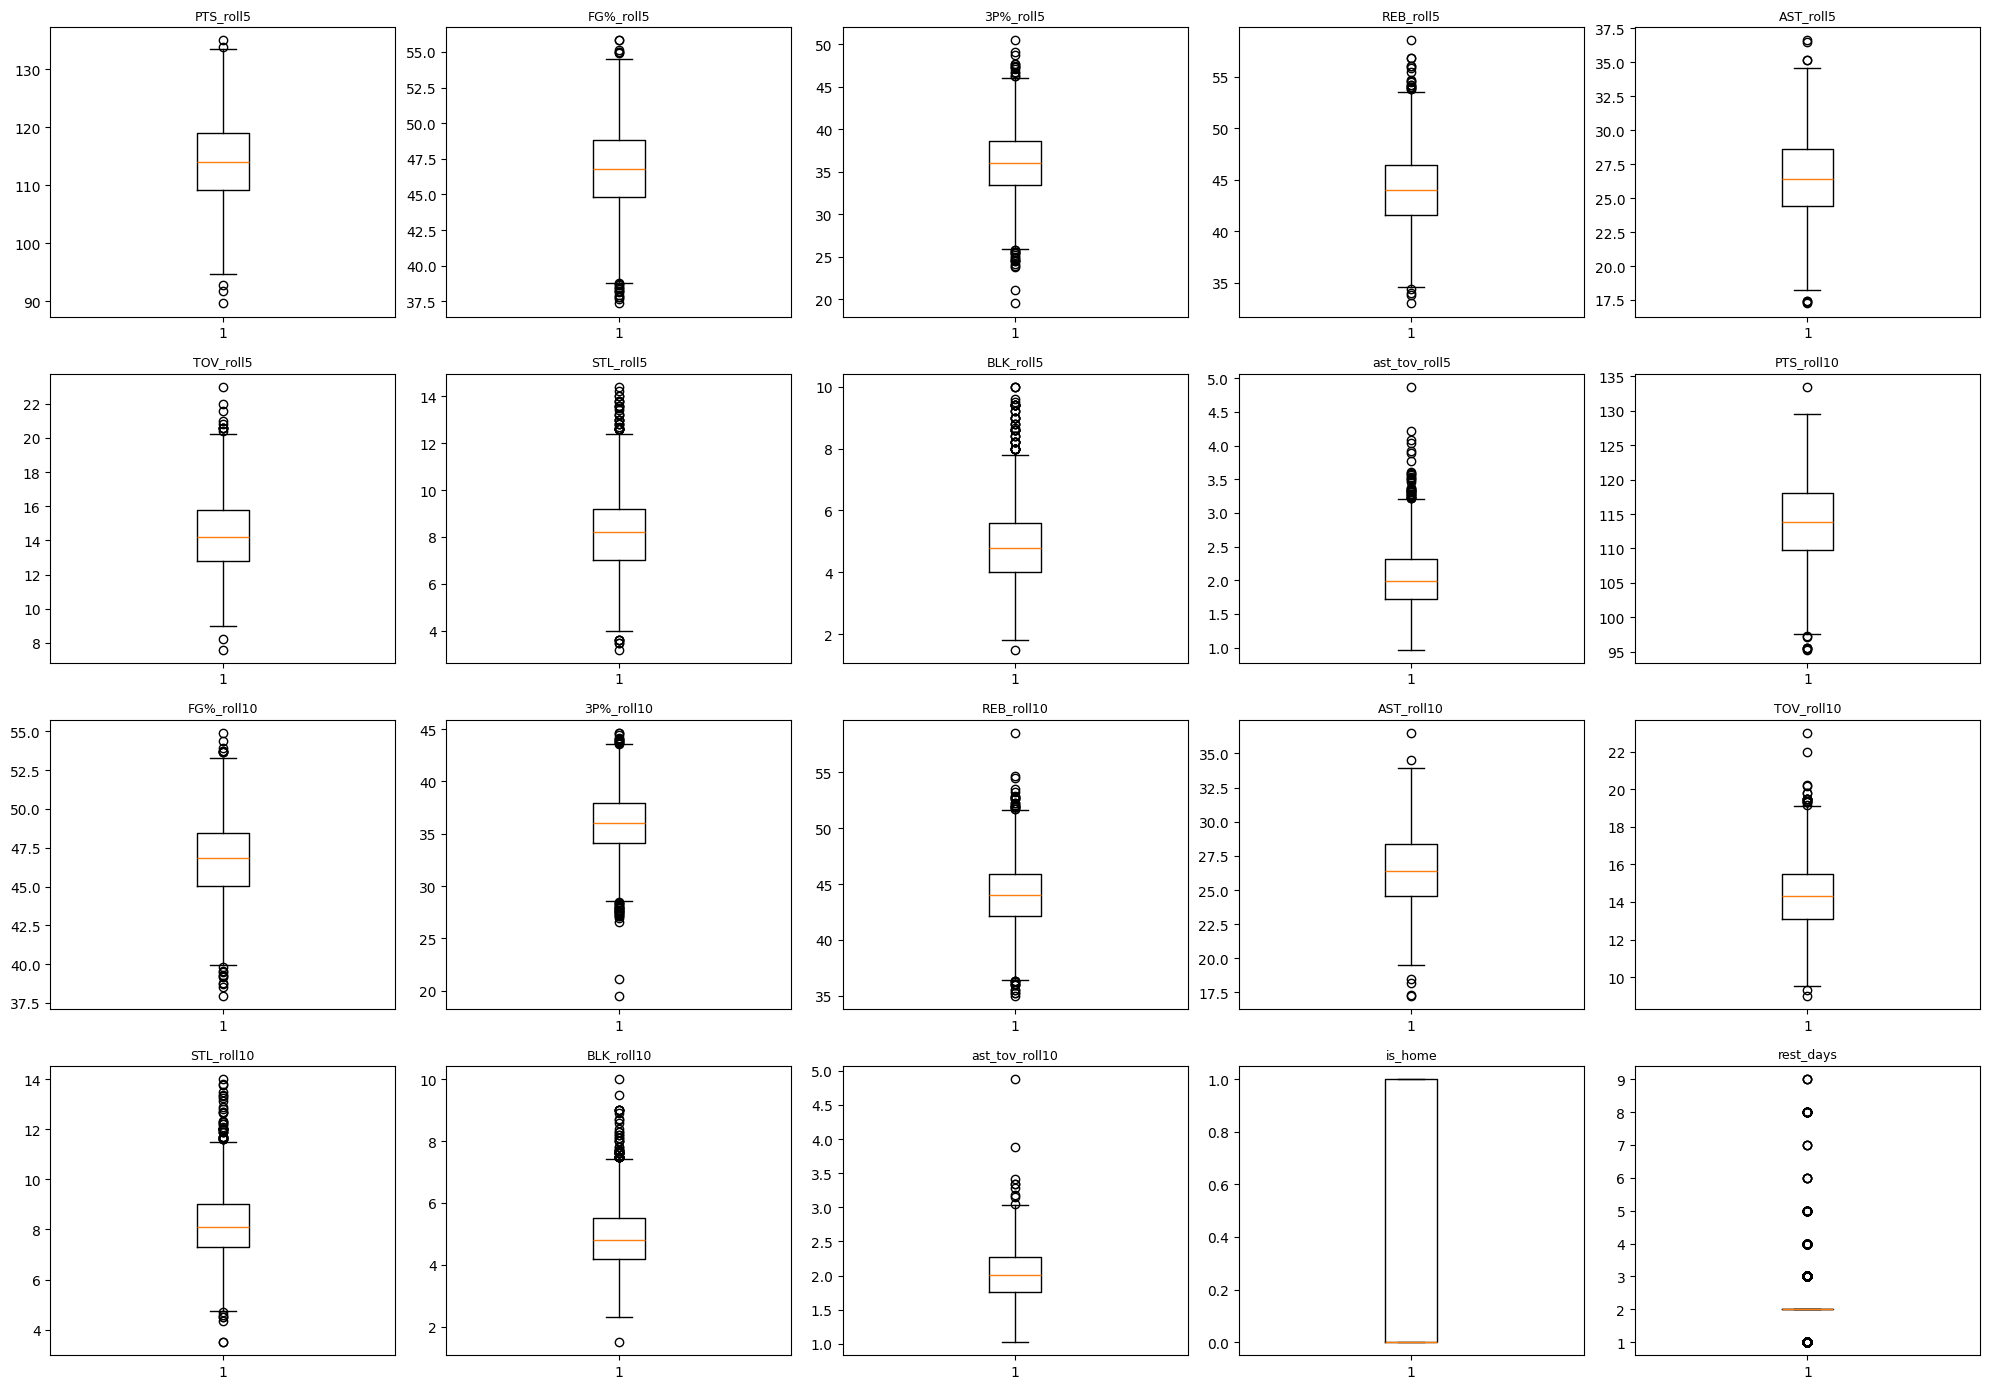

In [ ]:
# Visualize with boxplots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_model[col].dropna())
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

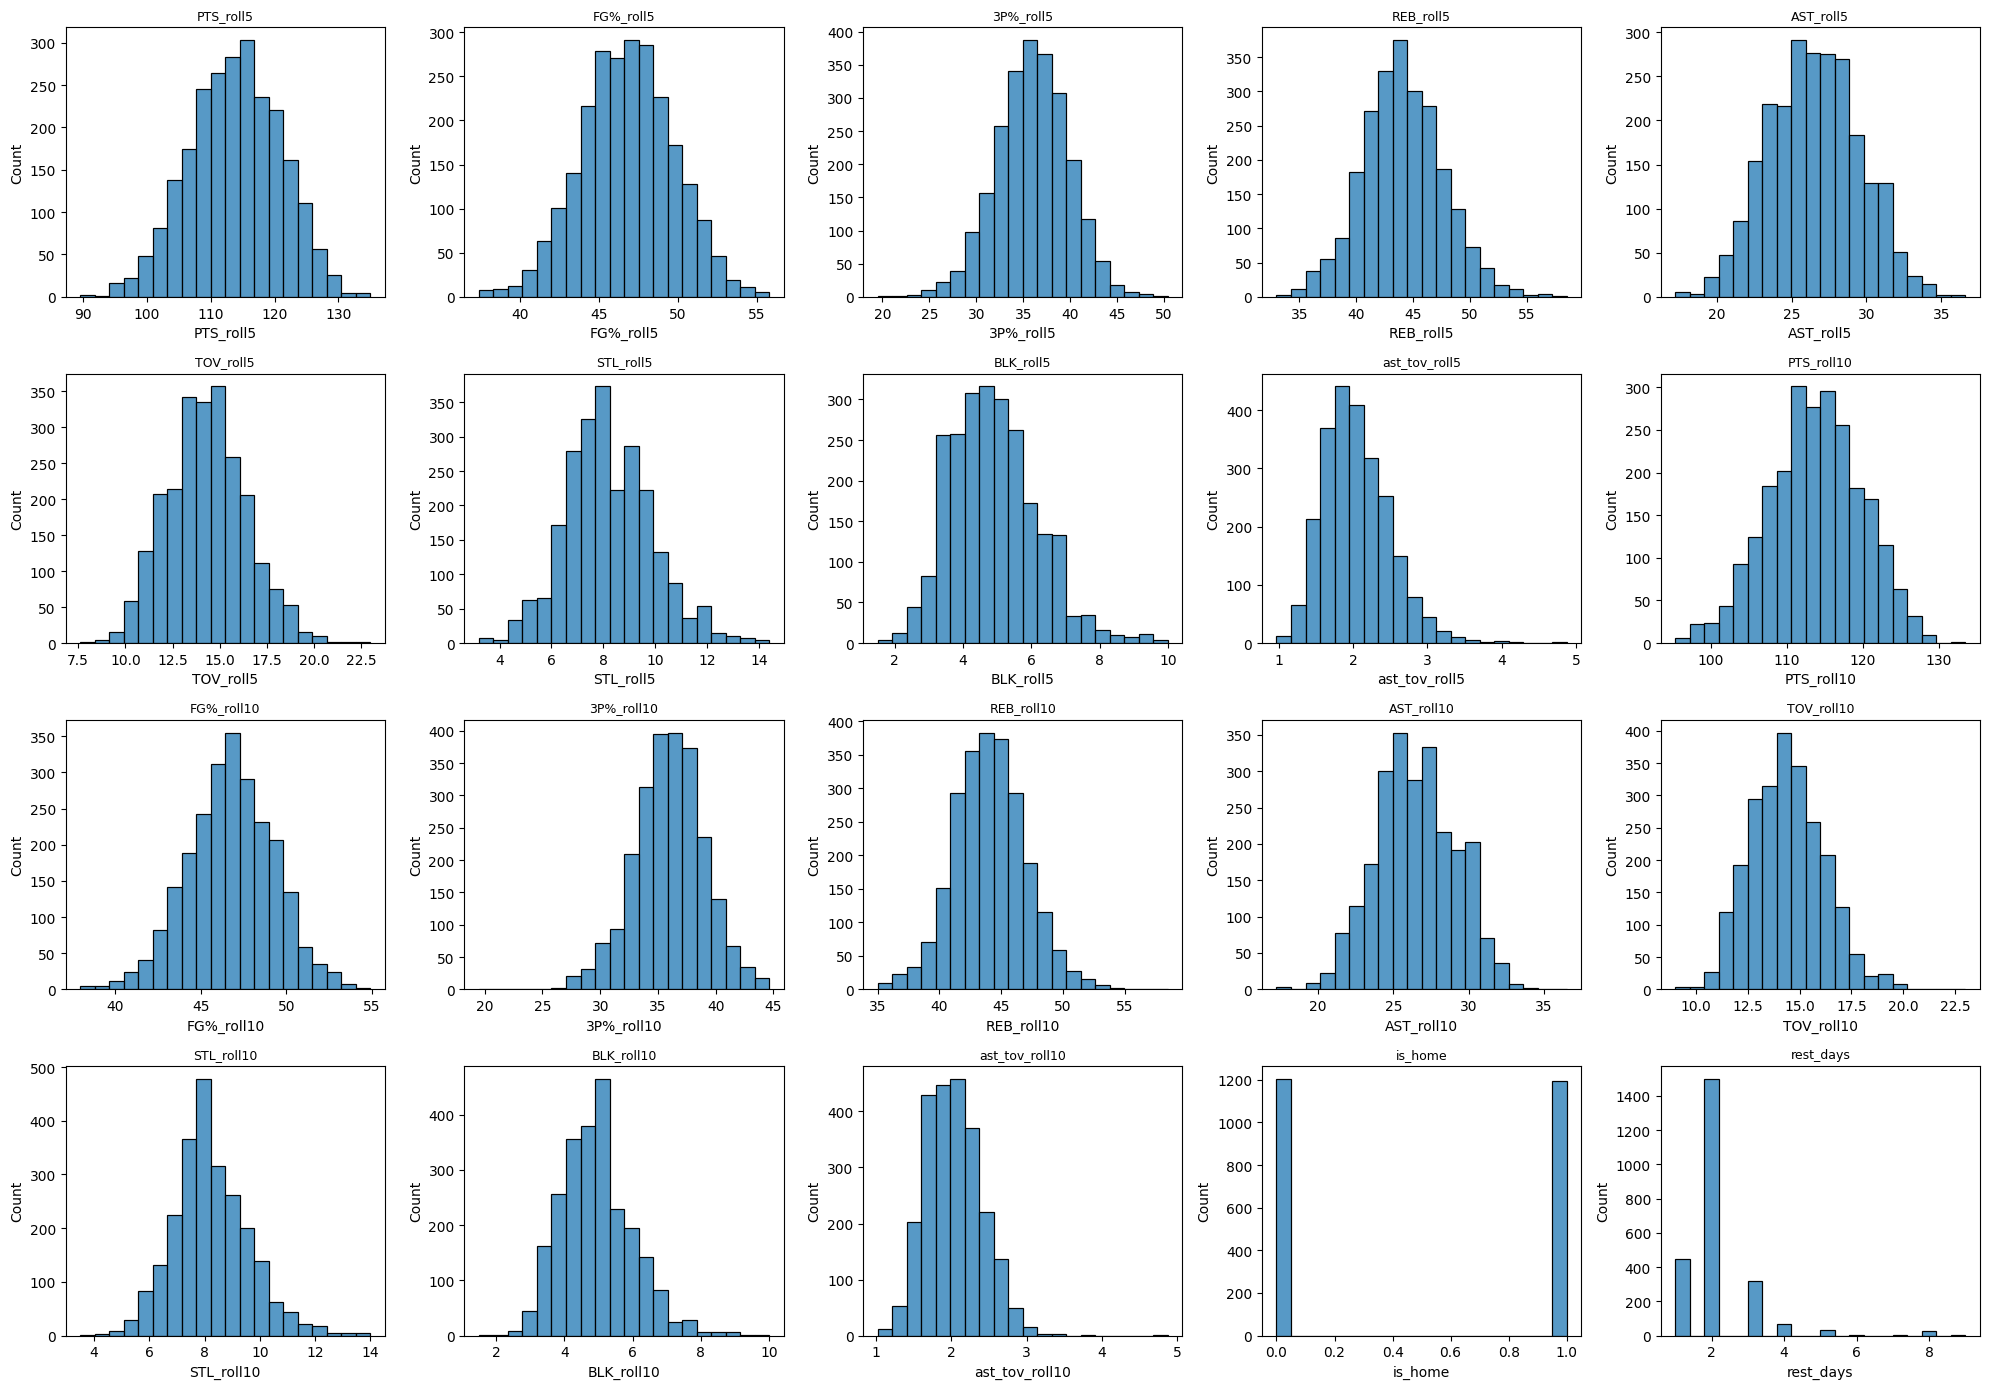

In [ ]:
#part 6: visualizations

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df_model[col].dropna(), bins=20, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

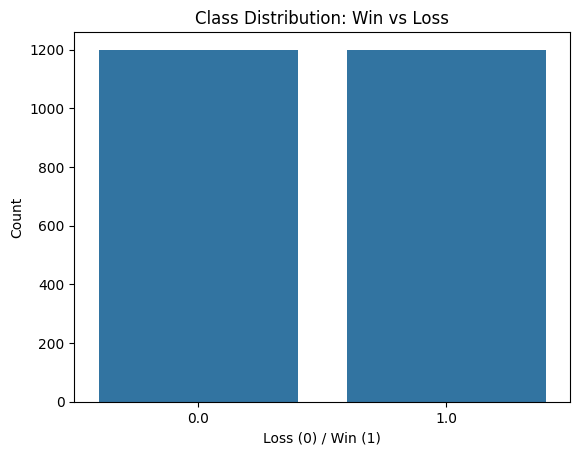

In [51]:
#bar chart of target variable
sns.countplot(x='win', data=df_model)
plt.title('Class Distribution: Win vs Loss')
plt.xlabel('Loss (0) / Win (1)')
plt.ylabel('Count')
plt.show()

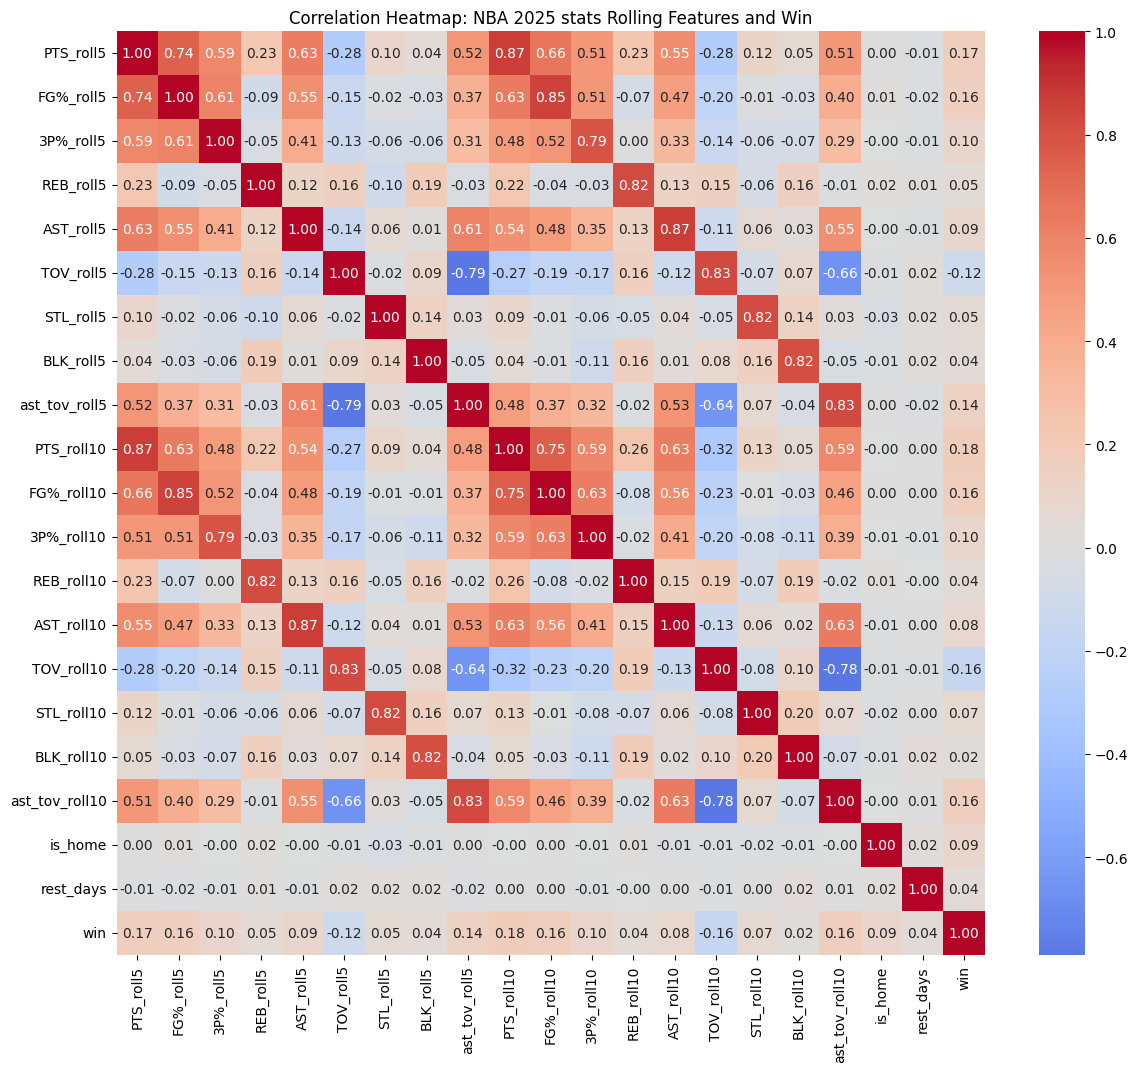

In [ ]:
#correlation matrix heatmap
plt.figure(figsize=(14, 12))
corr_cols = feature_cols + ['win']
sns.heatmap(df_model[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: NBA 2025 stats Rolling Features and Win')
plt.show()

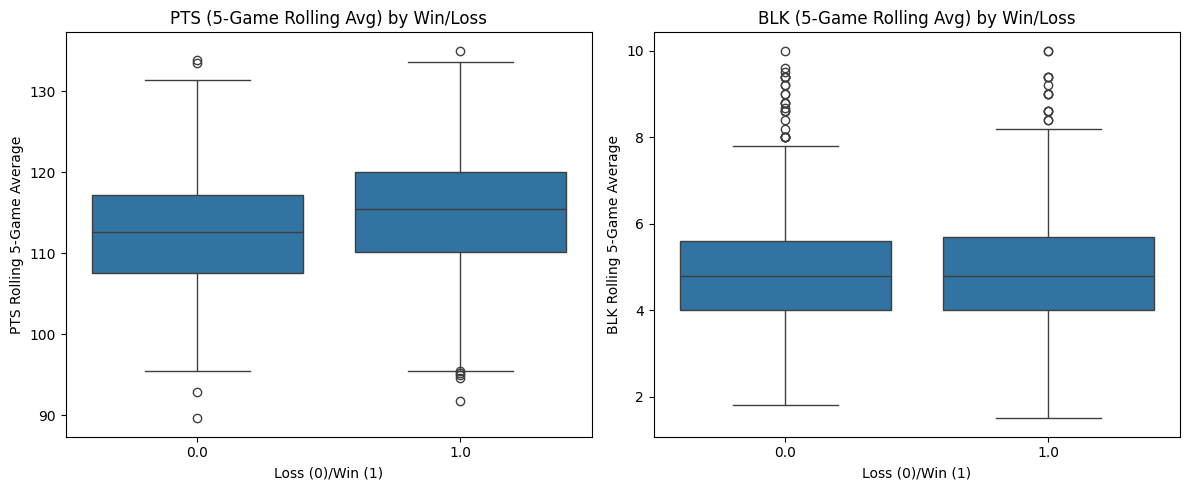

In [39]:
#boxplots comparing a feature across classes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='win', y='PTS_roll5', data=df_model, ax=axes[0])
axes[0].set_title('PTS (5-Game Rolling Avg) by Win/Loss')
axes[0].set_xlabel('Loss (0)/Win (1)')
axes[0].set_ylabel('PTS Rolling 5-Game Average')

sns.boxplot(x='win', y='BLK_roll5', data=df_model, ax=axes[1])
axes[1].set_title('BLK (5-Game Rolling Avg) by Win/Loss')
axes[1].set_xlabel('Loss (0)/Win (1)')
axes[1].set_ylabel('BLK Rolling 5-Game Average')

plt.tight_layout()
plt.show()

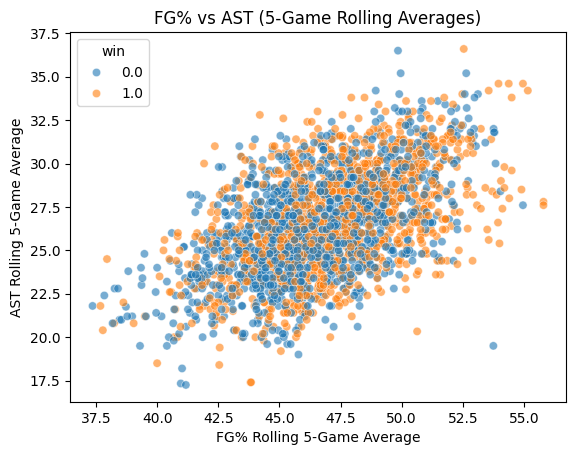

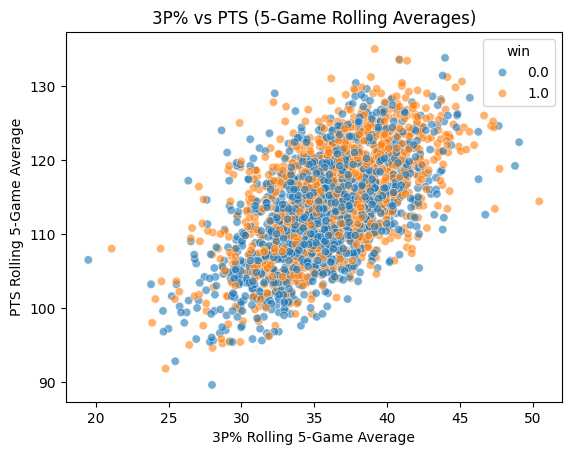

In [54]:
#Scatterplots for relationships between key variables
sns.scatterplot(x='FG%_roll5', y='AST_roll5', hue ='win', data=df_model, alpha=0.6)
plt.title('FG% vs AST (5-Game Rolling Averages)')
plt.xlabel('FG% Rolling 5-Game Average')
plt.ylabel('AST Rolling 5-Game Average')
plt.show()


sns.scatterplot(x='3P%_roll5', y='PTS_roll5', hue = 'win', data=df_model, alpha=0.6)
plt.title('3P% vs PTS (5-Game Rolling Averages)')
plt.xlabel('3P% Rolling 5-Game Average')
plt.ylabel('PTS Rolling 5-Game Average')
plt.show()

In [59]:
conn.close()

In [60]:
from google.colab import files
files.download('capstone.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>